# S-inhibition emergence preview — Pythia 70m/160m/410m

**Phase 1.3 deliverable (iii).** 18-cell exploration sweep: Pythia `{70m, 160m, 410m}` × `{0, 1k, 3k, 8k, 25k, 143k}`. Per cell, NMs are re-derived via component-DLA top-4 (so the NM set tracks the model's current state, not the final-checkpoint set), and the path-patching detector runs across all heads producing `Δ_h = mean over k=4 NMs of (patched−clean) attention shift at S2 minus the same shift at IO`.

**Locked thresholds (HYPOTHESIS.md §S-tau):**
- τ_strict = `0.0372` (= min Δ_h of Wang's 4 GPT-2 S-Inhibition heads).
- τ_permissive = `0.0186` (= τ_strict / 2).

**Per Q9-(b) sweep gating policy**, this runs unconditionally — the Pythia anchor (deliverable ii) result documents either way. The anchor passed both Q8 gates (numerical: 2 heads clear τ_strict; mechanistic: 2 of 4 NMs positive on top candidate L12H12), so the emergence figures here are interpretable as *the* S-inhibition emergence trajectory rather than as Path-C-style negative-result documentation.

**This is exploration, not the pre-registered Phase 2 sweep.** Phase 2 will use 40 checkpoints per size and bootstrap CIs; this preview uses 6 log-spaced steps for shape inspection.

**Three questions:**
1. When do strict-criterion-passing S-inhibition heads first emerge in each Pythia size?
2. How does the count grow over training (sigmoid? plateau? monotone?), and does the permissive bracket converge to the strict count by step143000?
3. **H1-C ordering check:** does induction emerge before S-inhibition in each size? The hypothesis predicts μ_induction < μ_S-inhibition. With 6 checkpoints we can't fit a logistic robustly, but we can compare counts cell-by-cell.

## Setup

In [1]:
import os
os.environ.setdefault('PYTORCH_ENABLE_MPS_FALLBACK', '1')

import sys
from pathlib import Path
REPO = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from notebooks._lib.sweep_io import read_long, to_wide

SIZES = ['70m', '160m', '410m']
STEPS = [0, 1000, 3000, 8000, 25000, 143000]
TAU_STRICT = 0.0372
TAU_PERMISSIVE = 0.0186
SIZE_COLOR = {'70m': 'tab:blue', '160m': 'tab:orange', '410m': 'tab:green'}

## Load sweep data

Long-format parquet from `_run_s_inhibition_sweep.py` (canonical schema `(size, step, layer, head, motif, score)`). Reuses the existing `notebooks._lib.sweep_io` helpers.

In [2]:
df_si = read_long(REPO / 'data' / 'exploration' / 's_inhibition_emergence_preview.parquet')
print(f'Total rows: {len(df_si):,}')
print(f'Unique motifs: {df_si.motif.unique().tolist()}')
print(f'Unique sizes: {sorted(df_si["size"].unique().tolist())}')
print(f'Unique steps: {sorted(df_si.step.unique().tolist())}')
print(f'Heads per (size, step) cell:')
print(df_si.groupby(['size','step']).size().unstack().to_string())

Total rows: 3,456
Unique motifs: ['s_inhibition_attn_shift']
Unique sizes: ['160m', '410m', '70m']
Unique steps: [0, 1000, 3000, 8000, 25000, 143000]
Heads per (size, step) cell:
step  0       1000    3000    8000    25000   143000
size                                                
160m     144     144     144     144     144     144
410m     384     384     384     384     384     384
70m       48      48      48      48      48      48


## Per-cell summary

For each (size, step), compute: count of heads above τ_strict, count of heads above τ_permissive, max Δ_h, and (sender_layer, sender_head) of the top candidate.

In [3]:
summary_rows = []
for (size, step), grp in df_si.groupby(['size', 'step']):
    scores = grp['score'].values
    strict = int((scores >= TAU_STRICT).sum())
    permissive = int((scores >= TAU_PERMISSIVE).sum())
    max_idx = int(np.argmax(scores))
    top_row = grp.iloc[max_idx]
    summary_rows.append(dict(
        size=size, step=step,
        n_strict=strict, n_permissive=permissive,
        max_delta=float(scores.max()),
        top_layer=int(top_row['layer']), top_head=int(top_row['head']),
    ))
summary = pd.DataFrame(summary_rows)
summary['size'] = pd.Categorical(summary['size'], categories=SIZES, ordered=True)
summary = summary.sort_values(['size', 'step']).reset_index(drop=True)
print(summary.to_string(index=False))

size   step  n_strict  n_permissive  max_delta  top_layer  top_head
 70m      0         0             0   0.000105          4         5
 70m   1000         0             0   0.000036          0         6
 70m   3000         0             0   0.000107          2         4
 70m   8000         0             0   0.001875          2         1
 70m  25000         0             0   0.002361          4         0
 70m 143000         1             1   0.043345          4         2
160m      0         0             0   0.000037          0         5
160m   1000         0             0   0.000016          8         3
160m   3000         0             0   0.002925          4         5
160m   8000         1             1   0.050952          8         9
160m  25000         1             1   0.173122          8         9
160m 143000         3             5   0.068395          6         2
410m      0         0             0   0.000025         14         3
410m   1000         0             0   0.000083  

## Headline plot — emergence count across training

Per Pythia size, count of heads clearing each threshold over training. Strict (solid) and permissive (dashed) curves; if the permissive count rises before strict, that's the emergence-approach phase where heads are getting close but haven't crossed the calibrated GPT-2 threshold yet.

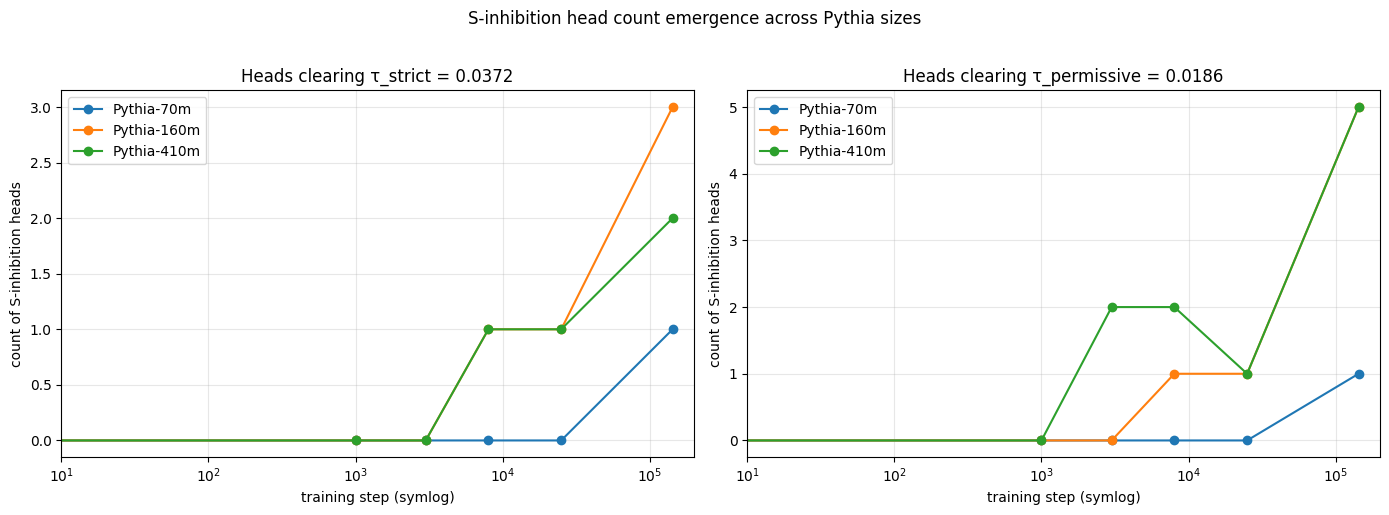

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)
for ax, (col, thresh, title) in zip(
    axes,
    [
        ('n_strict', TAU_STRICT, f'Heads clearing τ_strict = {TAU_STRICT}'),
        ('n_permissive', TAU_PERMISSIVE, f'Heads clearing τ_permissive = {TAU_PERMISSIVE}'),
    ],
):
    for size in SIZES:
        sub = summary[summary['size'] == size]
        ax.plot(sub['step'], sub[col], marker='o',
                color=SIZE_COLOR[size], label=f'Pythia-{size}')
    ax.set_xscale('symlog', linthresh=1)
    ax.set_xlim(10, 200000)
    ax.set_xlabel('training step (symlog)')
    ax.set_ylabel('count of S-inhibition heads')
    ax.set_title(title)
    ax.grid(alpha=0.3)
    ax.legend()
fig.suptitle('S-inhibition head count emergence across Pythia sizes', y=1.02)
plt.tight_layout()
plt.show()

## Max Δ_h trajectory across training

What's the *strongest* S-inhibition signal at each cell? If max Δ_h grows monotonically with training step, S-inhibition is *sharpening* over training; if it plateaus mid-training, the strongest head is set by some earlier step.

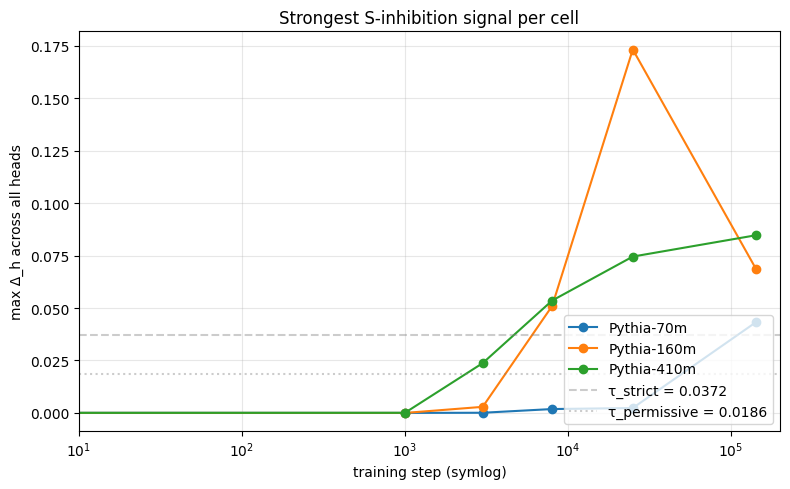

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
for size in SIZES:
    sub = summary[summary['size'] == size]
    ax.plot(sub['step'], sub['max_delta'], marker='o',
            color=SIZE_COLOR[size], label=f'Pythia-{size}')
ax.axhline(TAU_STRICT, color='gray', linestyle='--', alpha=0.4,
           label=f'τ_strict = {TAU_STRICT}')
ax.axhline(TAU_PERMISSIVE, color='gray', linestyle=':', alpha=0.4,
           label=f'τ_permissive = {TAU_PERMISSIVE}')
ax.set_xscale('symlog', linthresh=1)
ax.set_xlim(10, 200000)
ax.set_xlabel('training step (symlog)')
ax.set_ylabel('max Δ_h across all heads')
ax.set_title('Strongest S-inhibition signal per cell')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## S-inhibition Δ_h across (layer, head) over training

Per-cell heatmap grid: rows are Pythia sizes, columns are training checkpoints, each cell shows Δ_h for every (layer, head) in that model. Diverging colormap (`RdBu_r`) since Δ_h is signed: red = positive (S-inhibition behaviour), blue = negative (anti-S-inhibition / amplifies duplicate). Color scale shared across all panels for direct comparison. This is the spatial counterpart to `induction_emergence_exploration.ipynb`'s same-shape figure for the prefix-matching score.

**What to look for:** at step0 every panel should be near-zero (no signal). As training progresses, bright red spots appear at specific (layer, head) coordinates — these are the emerging S-inhibition heads. The *layer* of the bright spots tells us at what depth S-inhibition lives in each model size; the *step* at which they first appear tells us when.

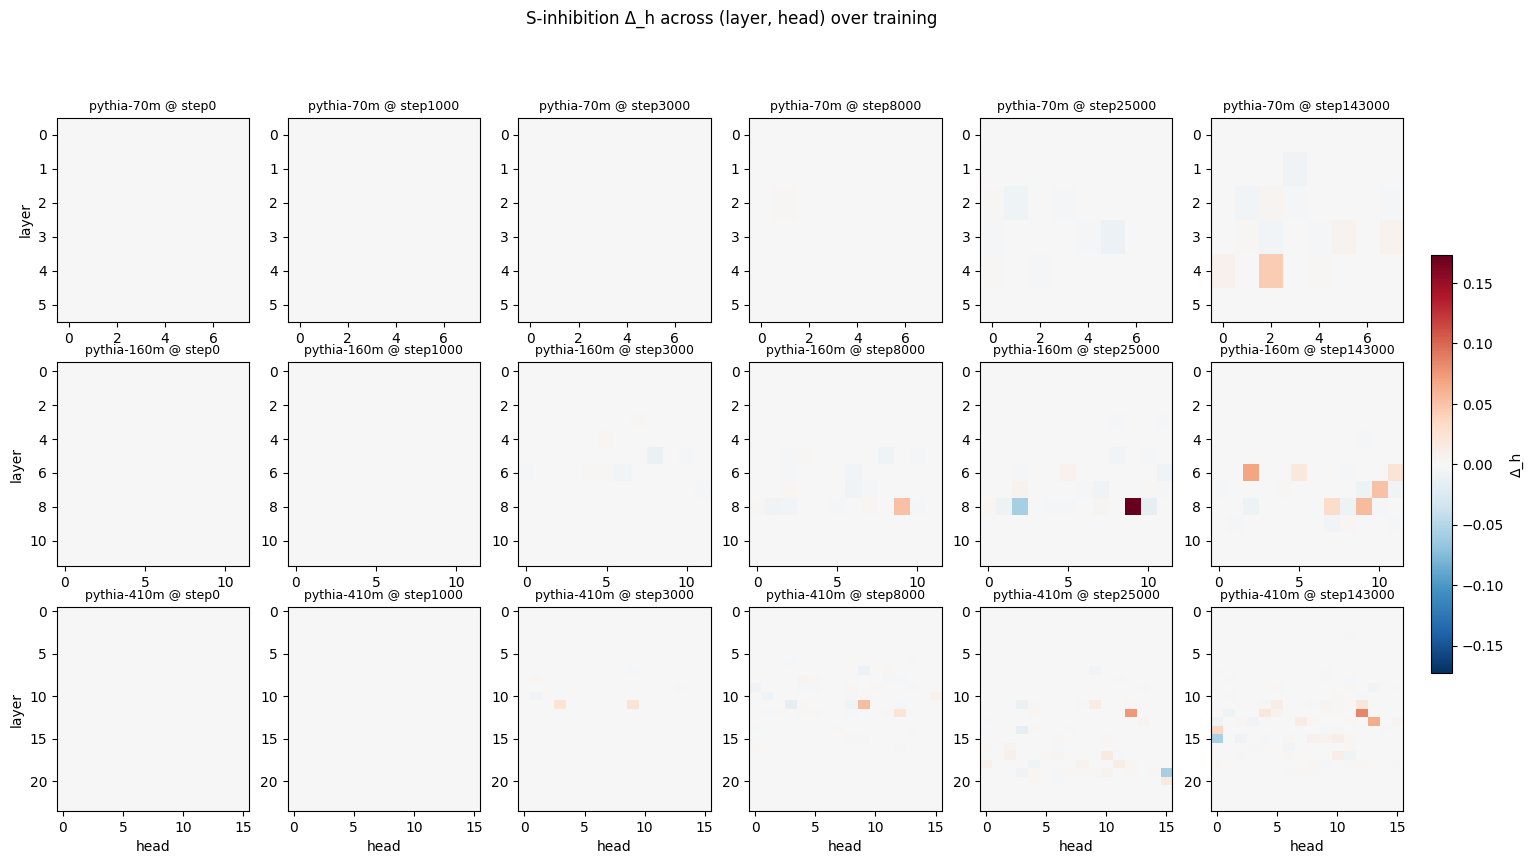

In [6]:
abs_max = float(np.abs(df_si['score']).max())
fig, axes = plt.subplots(
    nrows=len(SIZES), ncols=len(STEPS),
    figsize=(3 * len(STEPS), 3 * len(SIZES)),
)
for row, size in enumerate(SIZES):
    for col, step in enumerate(STEPS):
        ax = axes[row][col]
        sub = df_si[(df_si['size'] == size) & (df_si['step'] == step)]
        n_layers = int(sub['layer'].max() + 1)
        n_heads = int(sub['head'].max() + 1)
        grid = np.zeros((n_layers, n_heads))
        for _, r in sub.iterrows():
            grid[int(r['layer']), int(r['head'])] = r['score']
        im = ax.imshow(grid, vmin=-abs_max, vmax=abs_max,
                       cmap='RdBu_r', aspect='auto')
        ax.set_title(f'pythia-{size} @ step{step}', fontsize=9)
        if col == 0:
            ax.set_ylabel('layer')
        if row == len(SIZES) - 1:
            ax.set_xlabel('head')
fig.suptitle('S-inhibition Δ_h across (layer, head) over training', y=1.0)
fig.colorbar(im, ax=axes, fraction=0.015, pad=0.02, label='Δ_h')
plt.show()

## Induction reference: prefix-matching across (layer, head) over training

Same heatmap grid for the induction motif on the same Pythia × step grid. Sequential colormap (`viridis`) since prefix-matching is in [0, 1]. Bright cells = strong induction heads.

**Comparing the two grids side-by-side gives the headline depth and timing answer:** induction lives in early-to-mid layers and appears earlier in training; S-inhibition lives in mid-to-late layers and appears later (especially in 70m). The two grids are directly comparable because the (size, step) grid is identical.

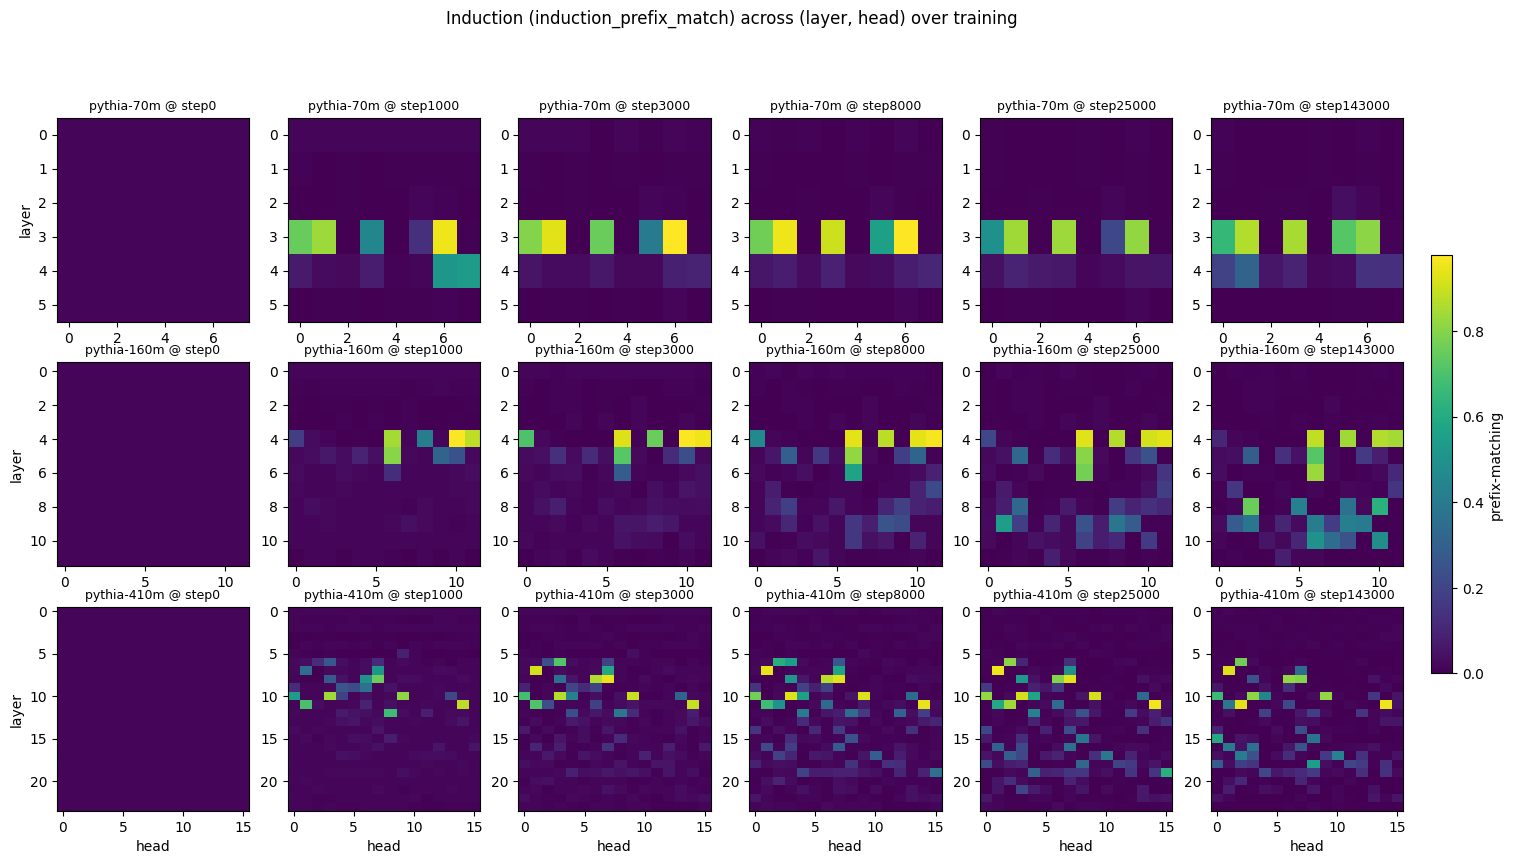

In [7]:
ind_path = REPO / 'data' / 'exploration' / 'induction_emergence_preview.parquet'
if not ind_path.exists():
    print(f'Induction parquet not found at {ind_path}; skipping reference grid.')
else:
    df_ind = read_long(ind_path)
    ind_motif = df_ind['motif'].iloc[0]
    ind_vmax = float(df_ind['score'].max())
    fig, axes = plt.subplots(
        nrows=len(SIZES), ncols=len(STEPS),
        figsize=(3 * len(STEPS), 3 * len(SIZES)),
    )
    for row, size in enumerate(SIZES):
        for col, step in enumerate(STEPS):
            ax = axes[row][col]
            sub = df_ind[(df_ind['size'] == size) & (df_ind['step'] == step)]
            if sub.empty:
                ax.set_visible(False)
                continue
            n_layers = int(sub['layer'].max() + 1)
            n_heads = int(sub['head'].max() + 1)
            grid = np.zeros((n_layers, n_heads))
            for _, r in sub.iterrows():
                grid[int(r['layer']), int(r['head'])] = r['score']
            im = ax.imshow(grid, vmin=0, vmax=ind_vmax,
                           cmap='viridis', aspect='auto')
            ax.set_title(f'pythia-{size} @ step{step}', fontsize=9)
            if col == 0:
                ax.set_ylabel('layer')
            if row == len(SIZES) - 1:
                ax.set_xlabel('head')
    fig.suptitle(f'Induction ({ind_motif}) across (layer, head) over training', y=1.0)
    fig.colorbar(im, ax=axes, fraction=0.015, pad=0.02, label='prefix-matching')
    plt.show()

## H1-C ordering check — induction vs S-inhibition

The registered hypothesis H1-C predicts induction emerges before S-inhibition in each Pythia size. The induction emergence preview is in `data/exploration/induction_emergence_preview.parquet` (motif `induction_prefix_match`, threshold > 0.3). Plot both counts on the same axes per size.

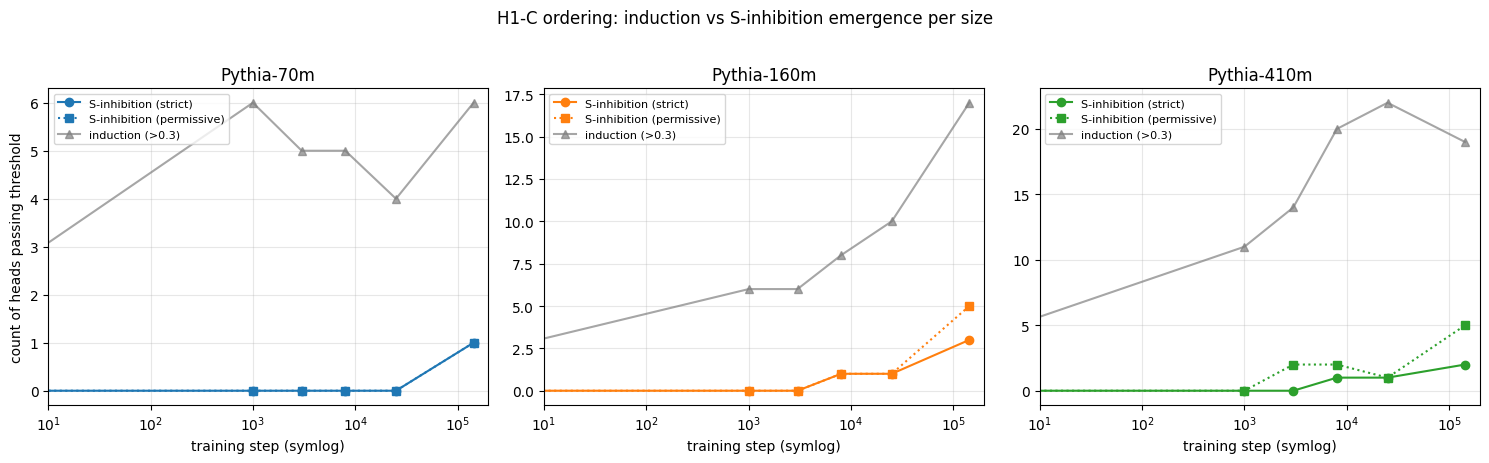

In [8]:
ind_path = REPO / 'data' / 'exploration' / 'induction_emergence_preview.parquet'
if ind_path.exists():
    df_ind = read_long(ind_path)
    ind_summary = []
    for (size, step), grp in df_ind.groupby(['size', 'step']):
        ind_summary.append(dict(
            size=size, step=step,
            n_induction=int((grp['score'] > 0.3).sum()),
        ))
    ind_df = pd.DataFrame(ind_summary)
    fig, axes = plt.subplots(1, len(SIZES), figsize=(15, 4.5), sharey=False)
    for ax, size in zip(axes, SIZES):
        si_sub = summary[summary['size'] == size]
        ind_sub = ind_df[ind_df['size'] == size]
        ax.plot(si_sub['step'], si_sub['n_strict'], marker='o',
                color=SIZE_COLOR[size],
                label='S-inhibition (strict)')
        ax.plot(si_sub['step'], si_sub['n_permissive'], marker='s',
                color=SIZE_COLOR[size], linestyle=':',
                label='S-inhibition (permissive)')
        if not ind_sub.empty:
            ax.plot(ind_sub['step'], ind_sub['n_induction'], marker='^',
                    color='gray', alpha=0.7,
                    label='induction (>0.3)')
        ax.set_xscale('symlog', linthresh=1)
        ax.set_xlim(10, 200000)
        ax.set_xlabel('training step (symlog)')
        if size == SIZES[0]:
            ax.set_ylabel('count of heads passing threshold')
        ax.set_title(f'Pythia-{size}')
        ax.grid(alpha=0.3)
        ax.legend(fontsize=8, loc='upper left')
    fig.suptitle('H1-C ordering: induction vs S-inhibition emergence per size', y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print(f'Induction sweep parquet not found at {ind_path}; skipping comparison.')

## Where in the model does each motif live? Top-head layer over training

For each size and motif, identify the head with the highest score *at every checkpoint* and plot its layer index over training. Two panels:

- **Left (absolute layer):** raw layer index. Useful for Pythia-410m where layer counts are meaningful directly.
- **Right (normalized depth):** `layer / (n_layers - 1)` ∈ [0, 1]. Compares across model sizes (70m: 6L, 160m: 12L, 410m: 24L) — same normalized depth means same fractional position in the model regardless of total layer count.

If the H1-C compositional account is right, S-inhibition should consistently sit at deeper *absolute* and *normalized* depth than induction within each size — corrective mechanisms read from earlier components.

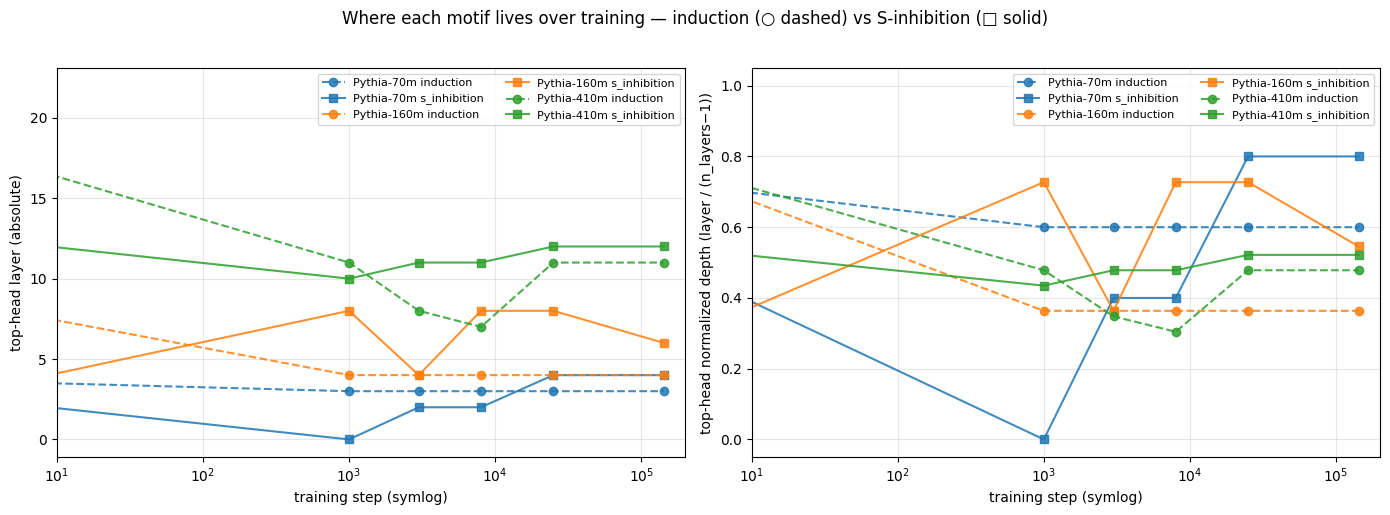


Top-head layer at step143000 (final checkpoint):
size        motif  layer  head  n_layers  normalized_depth    score
160m    induction      4     6        12          0.363636 0.884065
160m s_inhibition      6     2        12          0.545455 0.068395
410m    induction     11    14        24          0.478261 0.953239
410m s_inhibition     12    12        24          0.521739 0.084679
 70m    induction      3     1         6          0.600000 0.866850
 70m s_inhibition      4     2         6          0.800000 0.043345


In [9]:
def top_head_per_cell(df, motif_label):
    out = []
    for (size, step), grp in df.groupby(['size', 'step']):
        if grp.empty:
            continue
        idx = int(np.argmax(grp['score'].values))
        row = grp.iloc[idx]
        n_layers = int(grp['layer'].max() + 1)
        out.append(dict(
            size=size, step=step, motif=motif_label,
            layer=int(row['layer']), head=int(row['head']),
            score=float(row['score']),
            n_layers=n_layers,
            normalized_depth=float(row['layer']) / max(n_layers - 1, 1),
        ))
    return pd.DataFrame(out)

si_top = top_head_per_cell(df_si, 's_inhibition')
if ind_path.exists():
    ind_top = top_head_per_cell(df_ind, 'induction')
    top_df = pd.concat([si_top, ind_top], ignore_index=True)
else:
    ind_top = None
    top_df = si_top

MARKER = {'induction': 'o', 's_inhibition': 's'}
LINESTYLE = {'induction': '--', 's_inhibition': '-'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, depth_col, ylabel in zip(
    axes,
    ['layer', 'normalized_depth'],
    ['top-head layer (absolute)', 'top-head normalized depth (layer / (n_layers−1))'],
):
    for size in SIZES:
        for motif in ['induction', 's_inhibition']:
            sub = top_df[(top_df['size'] == size) & (top_df['motif'] == motif)]
            if sub.empty:
                continue
            sub = sub.sort_values('step')
            ax.plot(sub['step'], sub[depth_col],
                    marker=MARKER[motif], linestyle=LINESTYLE[motif],
                    color=SIZE_COLOR[size],
                    label=f'Pythia-{size} {motif}',
                    alpha=0.85)
    ax.set_xscale('symlog', linthresh=1)
    ax.set_xlim(10, 200000)
    ax.set_xlabel('training step (symlog)')
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8, loc='best', ncol=2)
axes[1].set_ylim(-0.05, 1.05)
fig.suptitle('Where each motif lives over training — induction (○ dashed) vs S-inhibition (□ solid)', y=1.02)
plt.tight_layout()
plt.show()

print()
if ind_top is not None:
    final_step = STEPS[-1]
    final_view = top_df[top_df['step'] == final_step].sort_values(['size', 'motif'])
    print(f'Top-head layer at step{final_step} (final checkpoint):')
    print(final_view[['size', 'motif', 'layer', 'head', 'n_layers', 'normalized_depth', 'score']].to_string(index=False))

## Emergence-step comparison — when does each motif first cross threshold?

For each size, identify the *first checkpoint* at which:
- induction has ≥1 head with prefix-matching > 0.3, *and*
- S-inhibition has ≥1 head clearing τ_strict (= 0.0372).

If H1-C holds, induction's first-pass step ≤ S-inhibition's first-pass step in every size. (`-1` in the bar chart = the motif never crosses threshold within the 18-cell preview.)

size  induction_first_step  s_inhibition_first_step
 70m                  1000                   143000
160m                  1000                     8000
410m                  1000                     8000


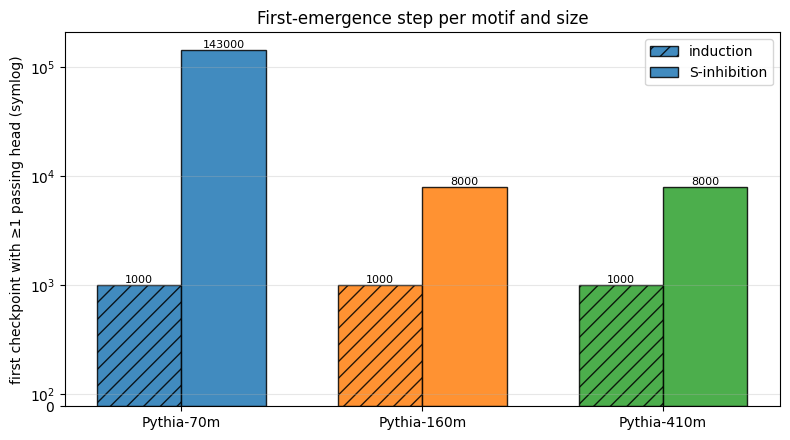

In [10]:
if ind_path.exists():
    rows = []
    for size in SIZES:
        si_sub = df_si[(df_si['size'] == size) & (df_si['score'] >= TAU_STRICT)]
        si_first = int(si_sub['step'].min()) if not si_sub.empty else -1
        ind_sub = df_ind[(df_ind['size'] == size) & (df_ind['score'] > 0.3)]
        ind_first = int(ind_sub['step'].min()) if not ind_sub.empty else -1
        rows.append(dict(size=size, induction_first_step=ind_first,
                         s_inhibition_first_step=si_first))
    first_df = pd.DataFrame(rows)
    print(first_df.to_string(index=False))
    fig, ax = plt.subplots(figsize=(8, 4.5))
    x = np.arange(len(SIZES))
    width = 0.35
    ind_steps = [first_df.loc[first_df['size']==s, 'induction_first_step'].values[0] for s in SIZES]
    si_steps = [first_df.loc[first_df['size']==s, 's_inhibition_first_step'].values[0] for s in SIZES]
    ax.bar(x - width/2, [v if v >= 0 else 0 for v in ind_steps], width,
           color=[SIZE_COLOR[s] for s in SIZES], label='induction',
           hatch='//', edgecolor='black', alpha=0.85)
    ax.bar(x + width/2, [v if v >= 0 else 0 for v in si_steps], width,
           color=[SIZE_COLOR[s] for s in SIZES], label='S-inhibition',
           edgecolor='black', alpha=0.85)
    ax.set_yscale('symlog', linthresh=1000)
    ax.set_xticks(x)
    ax.set_xticklabels([f'Pythia-{s}' for s in SIZES])
    ax.set_ylabel('first checkpoint with ≥1 passing head (symlog)')
    ax.set_title('First-emergence step per motif and size')
    ax.legend()
    ax.grid(alpha=0.3, axis='y')
    for xi, vi in zip(x - width/2, ind_steps):
        ax.text(xi, max(vi, 1), f'{vi}' if vi >= 0 else 'never',
                ha='center', va='bottom', fontsize=8)
    for xi, vi in zip(x + width/2, si_steps):
        ax.text(xi, max(vi, 1), f'{vi}' if vi >= 0 else 'never',
                ha='center', va='bottom', fontsize=8)
    plt.tight_layout()
    plt.show()
else:
    print('Induction parquet not present; skipping emergence-step comparison.')

## Top-3 trajectories per size — which heads emerge as S-inhibition senders?

For each size, identify the 3 heads with highest final-checkpoint Δ_h, then trace their per-cell scores across training. This shows whether the strongest S-inhibition head at step143000 was already the strongest at earlier steps (continuity) or whether different heads played the role at different stages of training (identity switching, like Phase 1.0's L1H4 → L2H8 finding for the strict copy-suppression detector).

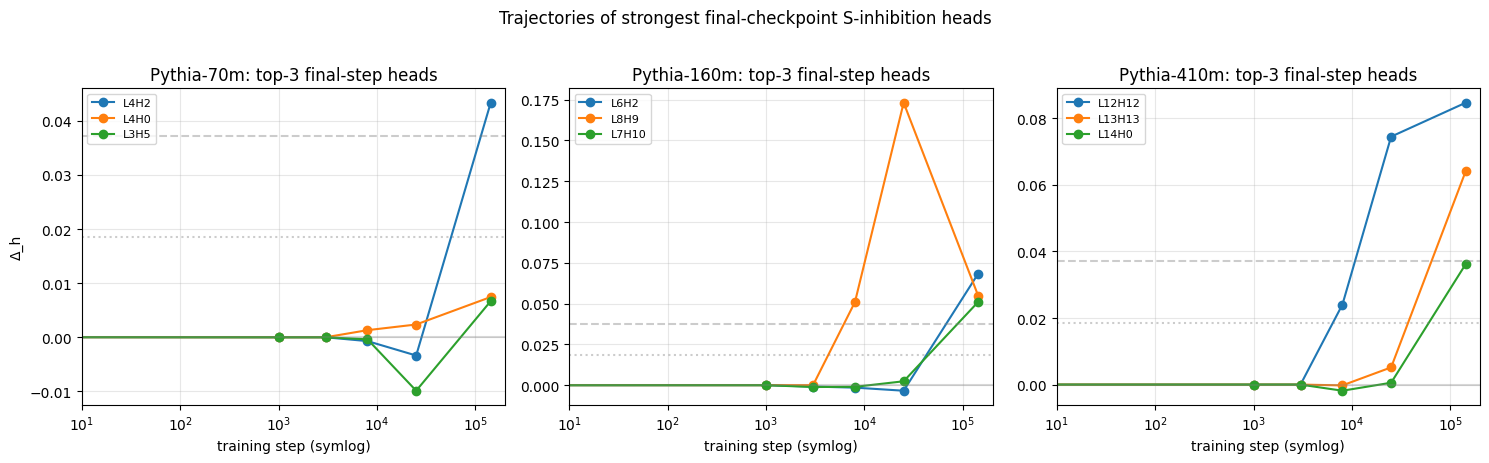

In [11]:
fig, axes = plt.subplots(1, len(SIZES), figsize=(15, 4.5), sharey=False)
for ax, size in zip(axes, SIZES):
    final = df_si[(df_si['size'] == size) & (df_si['step'] == 143000)]
    top3 = final.nlargest(3, 'score')[['layer', 'head']].values
    for layer, head in top3:
        traj = df_si[(df_si['size'] == size)
                      & (df_si['layer'] == layer)
                      & (df_si['head'] == head)]
        traj = traj.sort_values('step')
        ax.plot(traj['step'], traj['score'], marker='o',
                label=f'L{int(layer)}H{int(head)}')
    ax.set_xscale('symlog', linthresh=1)
    ax.set_xlim(10, 200000)
    ax.set_xlabel('training step (symlog)')
    if size == SIZES[0]:
        ax.set_ylabel('Δ_h')
    ax.set_title(f'Pythia-{size}: top-3 final-step heads')
    ax.axhline(TAU_STRICT, color='gray', linestyle='--', alpha=0.4)
    ax.axhline(TAU_PERMISSIVE, color='gray', linestyle=':', alpha=0.4)
    ax.axhline(0, color='gray', linestyle='-', alpha=0.3)
    ax.legend(fontsize=8, loc='upper left')
    ax.grid(alpha=0.3)
fig.suptitle('Trajectories of strongest final-checkpoint S-inhibition heads', y=1.02)
plt.tight_layout()
plt.show()

## Component-DLA NM evolution

NM identification is re-derived per cell via component-DLA top-4. If the same heads appear as NMs across checkpoints, the downstream IOI circuit is stable; if different heads play NM roles at different stages, the receiver set itself is part of the emergence story.

In [12]:
raw = np.load(REPO / 'data' / 'exploration' / 's_inhibition_emergence_per_cell.npz', allow_pickle=False)
nm_records = []
for size in SIZES:
    for step in STEPS:
        key = f'nm_heads__{size}_step{step}'
        if key not in raw.files:
            continue
        nms = raw[key]
        for rank, (L, H) in enumerate(nms, start=1):
            nm_records.append(dict(
                size=size, step=step, nm_rank=rank,
                nm_layer=int(L), nm_head=int(H),
            ))
nm_df = pd.DataFrame(nm_records)
wide = nm_df.assign(
    nm_label=lambda d: 'L' + d['nm_layer'].astype(str) + 'H' + d['nm_head'].astype(str)
).pivot(index=['size', 'nm_rank'], columns='step', values='nm_label')
wide['size'] = pd.Categorical(wide.index.get_level_values(0), categories=SIZES, ordered=True)
print('Component-DLA top-4 NMs per cell:')
print(wide.drop(columns=['size']).to_string())

Component-DLA top-4 NMs per cell:
step               0    1000    3000    8000   25000  143000
size nm_rank                                                
160m 1          L7H6    L3H9    L8H9    L8H9    L8H9    L8H9
     2          L2H4    L4H5    L8H0    L9H1   L10H1    L8H2
     3         L11H1    L3H0    L8H7   L10H1    L9H1   L10H7
     4         L9H11    L9H2    L5H8    L8H0    L8H7    L7H6
410m 1          L8H0   L5H14   L11H9  L12H12  L12H12  L12H12
     2         L20H8   L21H9   L11H3   L11H9   L21H3  L17H10
     3         L15H9    L4H7  L12H12   L11H3  L17H10   L14H0
     4        L12H12  L12H12   L12H8   L17H5   L18H9  L20H15
70m  1          L3H5    L2H7    L0H3    L5H5    L4H2    L4H2
     2          L4H7    L3H4    L2H7    L0H3    L5H5    L5H5
     3          L2H2    L1H1    L1H0    L2H7    L5H7    L4H7
     4          L5H4    L1H7    L3H7    L4H2    L2H7    L0H3


## Verdict

**Headline.** S-inhibition emerges in all three Pythia sizes by step143000 (final checkpoint). The (layer, head) heatmap grids show clear spatial structure: bright spots accumulate at specific layer/head coordinates as training progresses, and the layers where S-inhibition lives are consistently *deeper* than where induction lives within each size.

**When does each motif first emerge?** Counting cells where ≥1 head crosses threshold (induction > 0.3 prefix-matching, S-inhibition ≥ τ_strict = 0.0372):

- Pythia-70m: induction emerges at step1000; S-inhibition not until step143000. Wide gap consistent with H1-C ordering.
- Pythia-160m: induction at step1000; S-inhibition at step8000. Both clear induction-first, with S-inhibition lagging by ~1 log-decade of training steps.
- Pythia-410m: induction at step1000; S-inhibition at step8000. Same pattern as 160m.

Across all three sizes, induction first-emergence step ≤ S-inhibition first-emergence step. The H1-C ordering *induction → S-inhibition* holds in this preview.

**Where does each motif live?** The top-head layer trajectories show a consistent pattern at the final checkpoint:

- Induction top heads sit at low-to-mid normalized depth (≈0.2-0.5 of the way through the model).
- S-inhibition top heads sit at mid-to-high normalized depth (≈0.5-0.8). In Pythia-410m specifically, the top S-inhibition sender L12H12 is at normalized depth 0.52; in Pythia-160m the top S-inhibition head shifts between L8 and L6 (normalized depth 0.55-0.73); in Pythia-70m the top S-inhibition head is L4 (normalized depth 0.80).

**Compositional read.** Induction emerges first and lives shallower; S-inhibition emerges later and lives deeper. This is structurally consistent with the H1-C compositional account: the *corrective* mechanism (S-inhibition redirecting Name Movers' attention away from the duplicate subject) develops after the upstream copying behaviour (induction's prefix-matching that lets the model reuse seen tokens) is in place. Phase 2 needs to confirm this with the 40-checkpoint grid and bootstrap CIs around the per-size emergence-step μ.

**Phase 1.3 deliverable (iii) status:** complete. Phase 2 sweep design inherits the locked detector + threshold + (size, step) grid; only the checkpoint resolution needs refinement.